In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import llm_filter
import paper_dataset
import json
import tqdm
import re
import itertools
tqdm.tqdm.pandas()

/home/vico/personal_work_ms/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 10-20 15:27:53 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 10-20 15:27:57 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


## Languages

In [2]:
# def languages(item):
#     md = paper_dataset.get_markdown(item['pdf_url'])
#     title = item['title'] if item['title'] is not None else ''
#     answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_LANGUAGE, llm_filter.USER_PROMPT_LANGUAGE_MULTILINGUAL, {'title': title, 'content': md}, local=True, max_tokens=1024)
#     langs = llm_filter.extract_languages(answer)
#     return langs, answer

# evaluation = paper_dataset.load('data/evaluation_papers.jsonl')
# all_answers = []
# all_langs = []
# for item in tqdm.tqdm(evaluation.iloc):
#     langs, answer = languages(item)
#     all_answers.append(answer)
#     all_langs.append(langs)
# with open('evaluation_language_answer.json', 'wt') as f:
#     json.dump(all_answers, f)

In [3]:
def clean_lang(lang):    
    lang = re.sub(r'\(\w{2,3}\)', '', lang) # remove (xx) codes
    if lang == 'l':
        return ['latex']
    if lang.startswith('english'):
        return ['english']
    if re.search(r"\w{3}-\w{3}", lang): # Already countered
        return ''
    if lang.startswith('mboshi'):
        return ['mboshi (bantu)']
    if lang.startswith('none'): # Already countered as english
        return []
    if lang.startswith('indonesian'):
        return ['indonesian']
    if lang.startswith('czech'):
        return ['czech']
    if lang.startswith('30 programming languages'):
        return ['other (programming languages)']
    if lang.startswith('non-ascii'):
        return ['other']
    if lang.startswith('other languages'):
        return ['other']
    if lang.startswith('28 non-english languages'):
        return ['other']
    if lang == 'italian is not mentioned but the language pair de-en is used which implies that the target language is english and the source language is german.':
        return ['german', 'english']   
    if lang == 'italian is not mentioned but the following languages that are part of the xtreme benchmark and used in the paper for evaluation are':
        return [] 
    if lang.startswith('aymaran'):
        return ['aymara']
    if lang.startswith('bangla'):
        return ['bengali']
    if lang.startswith('mandarin'): # It is more often referred to as Chinese
        return ['chinese']
    if lang.startswith('modern greek'):
        return ['greek']
    if lang.startswith('modern chinese'):
        return ['chinese']
    if lang.startswith('slovene'):
        return ['slovenian']
    if lang == 'uk english':
        return ['english']
    if lang.startswith('traditional chinese'):
        return ['chinese (traditional)']
    clean_other = {            
        'n. lev. arabic': ['north levantine arabic'],
        'indian languages (including but not limited to hindi, as the paper mentions hundreds of indian languages)': ['indian languages'],
        'norwegian (including nynorsk, bokmål, west norwegian, east norwegian, and north norwegian)': ['norwegian', 'norwegian nynorsk', 'norwegian bokmål', 'west norwegian', 'east norwegian', 'north norwegian'],                
        'manx (mentioned as an example of a language with a small dataset in unimorph 4)': ['manx'],
        'bengali (bn_bd)': ['bengali'],
        'arabic (modern standard arabic, egyptian, levantine, gulf, and maghrebi)': ['arabic', 'modern standard arabic', 'egyptian arabic', 'levantine arabic', 'gulf arabic', 'maghrebi arabic'],
        'german (including swiss german and low saxon)': ['german', 'swiss german', 'low saxon'],        
        'finnish (including six dialect groups': ['finnish'],
        # 'mandarin chinese (standard beijing)': ['mandarin'],        
        'wolastoqey (also known as passamaquoddy-maliseet)': ['wolastoqey'],
        'odawa (a dialect of ojibwe)': ['odawa (ojibwe)'],
        }
    return clean_other.get(lang, [lang.strip()])
    
    
    

In [4]:
evaluation = paper_dataset.load('data/evaluation_papers.jsonl')
with open('data/evaluation_language_answer.json') as f:
    all_answers = json.load(f)
all_langs = [llm_filter.extract_languages(i) for i in tqdm.tqdm(all_answers)]
# tmp = []
# for sample in all_langs:    
#     clean_sample = itertools.chain.from_iterable([clean_lang(i) for i in sample])
#     clean_sample = sorted(list(set(clean_sample)))
#     tmp.append(clean_sample)
# all_langs = tmp

# evaluation['languages'] = all_langs
# evaluation.to_json('data/evaluation_papers.jsonl', orient='records', lines=True)

100%|██████████| 173/173 [00:00<00:00, 41092.68it/s]


In [5]:
for i, ans in enumerate(all_answers):
    print("\n\n")
    print(i, "====================")
    print(ans)
    print("====================")
    print(llm_filter.extract_languages(ans))
    print("\n\n")




0 ====================
Based on the paper, the languages mentioned that are used as test cases, evaluation datasets, or experimental targets are:

1. Danish
2. English
['english', 'danish']






1 ====================
Here is the list of languages mentioned in the paper that are used as test cases, evaluation datasets, or experimental targets:

1. Kalaallisut (West Greenlandic)
2. Danish
3. Inuktitut
4. Nahuatl
5. Raramuri
6. Shipibo-Konibo
7. Wixarika
8. Quechua
9. Ainu
10. Tunumiisut (East Greenlandic)
11. Inuktun (North Greenlandic)
['ainu', 'shipibo-konibo', 'nahuatl', 'quechua', 'inuktun (north greenlandic)', 'kalaallisut (west greenlandic)', 'tunumiisut (east greenlandic)', 'inuktitut', 'raramuri', 'wixarika', 'danish']






2 ====================
Based on the provided paper, the language mentioned that is used as a test case, evaluation dataset, or experimental target is:

1. Chinese 

Note that the paper specifically focuses on Historical Chinese sources from 1900 to 1950,

In [5]:
unique_langs = []
for i in all_langs:
    unique_langs.extend(i)
unique_langs = list(set(unique_langs))

clean_unique_langs = [clean_lang(i) for i in unique_langs]
clean_unique_langs = [j for i in clean_unique_langs for j in i if j != '']
clean_unique_langs = list(set(clean_unique_langs))
print(len(clean_unique_langs))
# sorted(clean_unique_langs)

324


In [6]:
no_lang = evaluation[evaluation['languages'].apply(lambda x: len(x) == 0 or x == [[]])]
for i in no_lang['title']:
    print(i)
    print('-'*20)

Protein Structure Tokenization: Benchmarking and New Recipe
--------------------


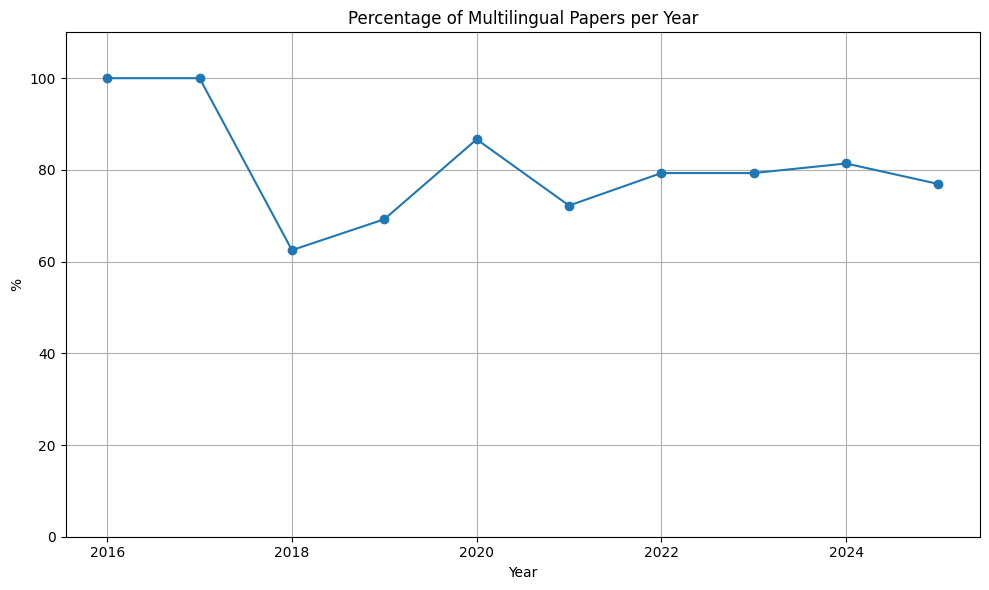

In [38]:
# Plot the number of papers that have 'exclusive_english' == False over the years, normalize by the total number of papers per year
years = sorted(evaluation['year'].unique())
exclusive_counts = []
total_counts = []       
for year in years:
    year_data = evaluation[evaluation['year'] == year]
    exclusive_count = year_data[year_data['exclusive_english'] == False].shape[0]
    total_count = year_data.shape[0]
    exclusive_counts.append(exclusive_count)
    total_counts.append(total_count)
plt.figure(figsize=(10, 6))
plt.plot(years, [e / t * 100 if t > 0 else 0 for e, t in zip(exclusive_counts, total_counts)], marker='o')
plt.title('Percentage of Multilingual Papers per Year')
plt.xlabel('Year')
plt.ylabel('%')
plt.ylim(0, 110)
plt.grid(True)
plt.tight_layout()
plt.show()

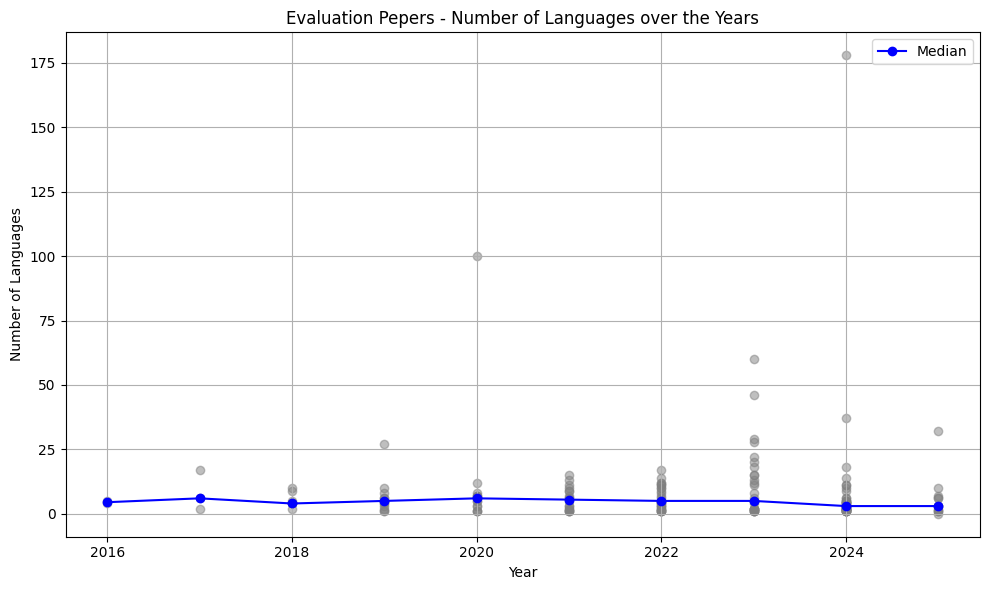

In [41]:
years = sorted(evaluation['year'].unique())
avg_lang_counts = []

medians = []
all_years = []
all_lang_counts = []

for year in years:
    year_data = evaluation[evaluation['year'] == year]
    lang_lens = year_data['languages'].apply(len)
    all_years.extend([year] * len(lang_lens))
    all_lang_counts.extend(lang_lens)
    medians.append(lang_lens.median())

plt.figure(figsize=(10, 6))

# Number of languages per year
plt.scatter(all_years, all_lang_counts, color='gray', alpha=0.5, label='_nolegend_')
# Median number of languages per year
plt.plot(years, medians, color='blue', marker='o', label='Median')

plt.title('Evaluation Pepers - Number of Languages over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Languages')
# plt.yscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
evaluation[evaluation['languages'].apply(len) > 75] ## 11, 128
paper_dataset.print_sample(evaluation.loc[11])
paper_dataset.print_sample(evaluation.loc[128])

Title: Are Character-level Translations Worth the Wait? Comparing {B}y{T}5 and m{T}5 for Machine Translation
Author(s): Edman, Lukas and Sarti, Gabriele and Toral, Antonio and van Noord, Gertjan and Bisazza, Arianna
Year: 2024
Venue: None (ACL)
Volume: Transactions of the Association for Computational Linguistics
--------------------------------------------------------------------------------
Abstract:
   Pretrained character-level and byte-level language models have been
   shown to be competitive with popular subword models across a range of
   Natural Language Processing tasks. However, there has been little
   research on their effectiveness for neural machine translation (NMT),
   particularly within the popular pretrain-then-finetune paradigm. This
   work performs an extensive comparison across multiple languages and
   experimental conditions of character- and subword-level pretrained
   models (ByT5 and mT5, respectively) on NMT. We show the effectiveness of
   character-level

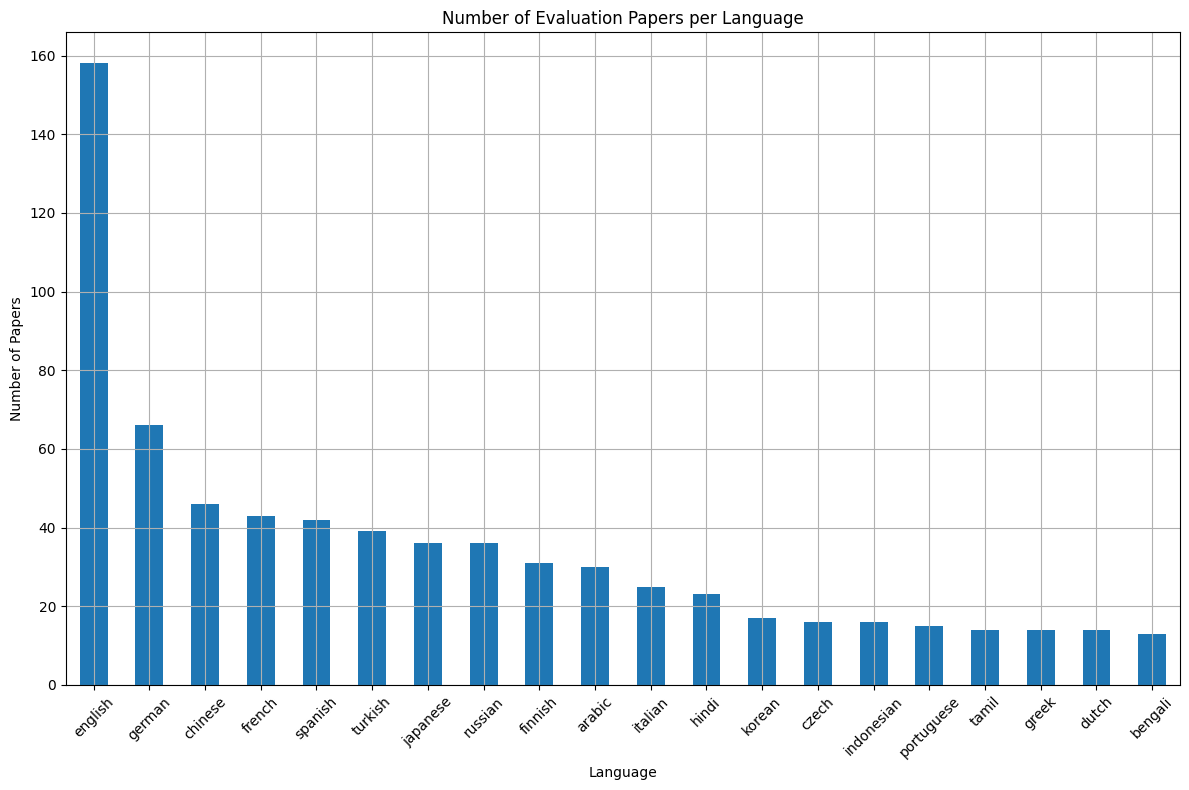

In [44]:
# PLot histogram of the number of papers per language
all_langs = [lang for sublist in evaluation['languages'].tolist() for lang in sublist]
all_langs = pd.Series(all_langs).value_counts()
top_lang_counts = all_langs.head(20)
plt.figure(figsize=(12, 8))
top_lang_counts.plot(kind='bar')
plt.title('Number of Evaluation Papers per Language')
plt.xlabel('Language')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

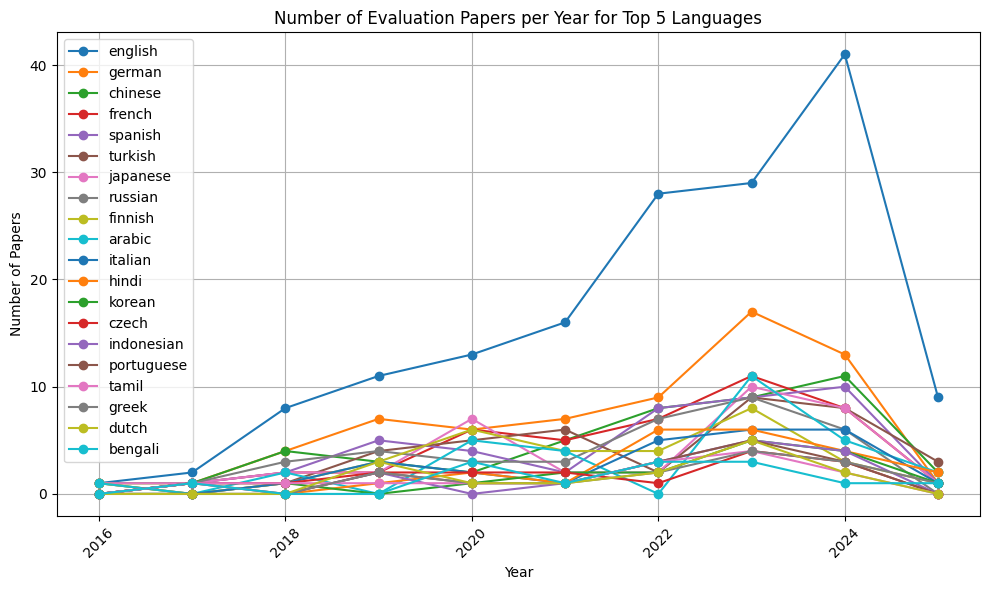

In [45]:
# Plot the number of papers over the years for the top 5 languages
years = sorted(evaluation['year'].unique())
all_langs = [lang for sublist in evaluation['languages'].tolist() for lang in sublist]
all_langs = pd.Series(all_langs).value_counts()
top_languages = all_langs.head(20).index.tolist()
plt.figure(figsize=(10, 6))
for lang in top_languages:
    lang_counts = []
    for year in years:
        year_data = evaluation[evaluation['year'] == year]
        count = year_data[year_data['languages'].apply(lambda x: lang in x)].shape[0]
        lang_counts.append(count)
    plt.plot(years, lang_counts, marker='o', label=lang)
plt.title('Number of Evaluation Papers per Year for Top 5 Languages')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# # 'western', 'chinese', 'english', 'arabic', 'indic', 'programming', 'african', 'asian', 'australian', 'other'
# english_group = [
# 'old english','african american english','english','british sign language', 
# 'american sign language',
# ]
 
# western_group = [ # split in major/national and other?
# 'limburgish','norwegian','swedish','old irish','swiss german',
# 'occitan','macedonian','greek','galician','ladin','venetian',
# 'hungarian','breton','ingrian','dutch','scottish gaelic', 
# 'low german','serbian','albanian','latgalian','ludian','basque',
# 'estonian','west frisian','ukrainian','french','icelandic', 
# 'portuguese','german','catalan','sicilian','danish','neapolitan',
# 'luxembourgish','bulgarian','gaelic','czech','slovenian',
# 'european languages','welsh','low saxon','middle french',
# 'middle high german','gothic','north norwegian','old french',
# 'lower sorbian','polish','lombard','lithuanian','bosnian',
# 'north frisian','norman','slovakian','mexican spanish', 
# 'middle low german','irish','romance languages','esperanto',
# 'old church slavonic','finnish','latvian','west norwegian',
# 'slavic languages','italian','ancient greek','old saxon','latin', 
# 'afrikaans','friulian','upper sorbian','tosk','silesian','romanian',
# 'croatian','spanish','slovak','alsatian german','cornish','russian',
# 'east norwegian','belarusian','manx','norwegian bokm','norwegian bokmål',
# 'norwegian nynorsk','karelian','eastern yiddish','yiddish','livvi',
# 'votic','picard','asturian','northern sami','kashubian','veps',
# 'faroese','livonian',
# ]


# arabic_group = [
# 'egyptian arabic','mesopotamian arabic','arabic','tunisian arabic',
# 'modern standard arabic (latin)','levantine arabic','maghrebi arabic',
# 'maltese','south levantine arabic','north levantine arabic',
# 'modern standard arabic','classical arabic','najdi arabic',
# 'algerian arabic','gulf arabic','moroccan arabic',
# ]

# semitic_group = [ # Not arabic
# 'hebrew','classical syriac','akkadian', 'tigrinya',
# ]

# indic_group = [
# 'devanagari','konkani','dogri','chhattisgarhi','gujarati','punjabi',
# 'indian languages','hindi','eastern panjabi','bengali',
# 'kashmiri (arabic script)','kashmiri (devanagari script)','sindhi',
# 'kannada','sinhala','urdu','sanskrit','malayalam','tulu','awadhi',
# 'maithili','bhojpuri','dravidian','assamese',
# 'meiteilon (manipuri)', # sino-tibetan
# 'meitei', # sino-tibetan
# 'pali','telugu','odia','santali','magahi','marathi','braj bhasha',
# 'tamil',
# ]

# programming_group = [
# 'java', 'javascript', 'python', 'mathml', 'php','go','latex',
# 'ruby', 'other (programming languages)',
 
# ]

# african_group = [ # split?
# 'mboshi (bantu)','ewe','fon','shona','twi','african languages', 
# 'setswana','sesotho','isixhosa','rundi','kinyarwanda','umbundu',
# 'tumbuka','xhosa','bemba','igbo','yoruba','swahili','zulu',
# 'bambara','mossi','dyula','akan','kabiyè','northern sotho','ganda',
# 'tsonga','kikongo','kikuyu','chokwe','siswati','kamba','southwestern dinka',
# 'tamasheq','sango','amharic','nuer','kabiy','kimbundu','somali',
# 'hausa','central kanuri','west central oromo','tswana','wolof',
# 'luo','lingala','kabuverdianu',
# ]

# sinotibetan_group = [
# 'chinese (simplified)','chintang','dzongkha','chinese','yue chinese',
# 'ancient chinese','cantonese','chinese (traditional)',
# 'standard tibetan','tibetan','classical chinese','jingpho','mizo',
# 'myanmar','burmese','khaling','yongning na',
# ]

# asian_group = [ # austoronesian, turkic, other?
# 'filipino', # austronesian
# 'shan', # tai
# 'nepali', # indo-aryan
# 'mongolian', # mongolic
# 'cebuano', # austronesian
# 'tagalog', # austronesian
# 'sundanese', # austronesian
# 'japanese','korean','austronesian','halh mongolian','vietnamese',
# 'khakas', # turkic
# 'south azerbaijani','classical armenian','central kurdish','uzbek',
# 'azerbaijani','kurdish','farsi','armenian','northern kurdish',
# 'kazakh','turkmen','turkish','kyrgyz',
# 'pangasinan', # austronesian
# 'persian','uyghur','pashto','georgian',
# 'banjar', # austronesian
# 'fijian', # austronesian
# 'samoan', # austronesian
# 'kabardian', # caucasian
# 'waray', # austronesian
# 'altaic', # turkic?
# 'malaysian', # austronesian
# 'dari',
# 'crimean tatar','tatar',
# 'indonesian', # austronesian
# 'malay','standard malay', # austronesian
# 'adyghe',
# 'bontoc', # austronesian
# 'ainu', # japanese
# 'bashkir', # turkic
# 'khmer',
# 'acehnese', # austronesian
# 'tajik',
# 'thai',
# 'javanese', # austronesian
# ]

# american_group = [ # north, central, south?
# 'chatino','central aymara','aymara','guarani','quechua', 
# 'yucatec mayan','navajo','cherokee','yorem nokki',"itza'",
# 'tepehua','yupik','kalaallisut (west greenlandic)',
# 'tunumiisut (east greenlandic)','inuktun (north greenlandic)',
# 'greenlandic','inuktitut','yupik','hupa','chickasaw','asháninka',
# 'wixarika','seneca','bribri','mexicanero','popoluca','raramuri',
# 'nahuatl','odawa (ojibwe)','plains cree','arapaho','hñähñu',
# ]

# australian_group = [
# 'kunwinjku','maori','murrinhpatha',
# ]

# other_group = [
# 'tok pisin', # eng creole
# 'other'
# 'sumerian',
# 'haitian creole', # french creole
# 'papiamento', # dutch creole
# ]

# group_map = {}
# for lang in english_group:
#     group_map[lang] = 'english'
# for lang in western_group:
#     group_map[lang] = 'western'
# for lang in arabic_group:
#     group_map[lang] = 'arabic'
# for lang in semitic_group:
#     group_map[lang] = 'semitic'
# for lang in indic_group:
#     group_map[lang] = 'indic'
# for lang in programming_group:
#     group_map[lang] = 'programming'
# for lang in african_group:
#     group_map[lang] = 'african'
# for lang in sinotibetan_group:
#     group_map[lang] = 'sinotibetan'
# for lang in asian_group:
#     group_map[lang] = 'asian'
# for lang in american_group:
#     group_map[lang] = 'american'
# for lang in australian_group:
#     group_map[lang] = 'australian'
# for lang in other_group:
#     group_map[lang] = 'other'

In [9]:
# Language of interest
english_group = [
'old english','african american english','english','british sign language', 
'american sign language',
]
 
national_euro_group = [ # split in major/national and other?
'norwegian','swedish','macedonian','greek','hungarian',
'dutch','albanian','estonian','ukrainian','french','icelandic', 
'portuguese','german','danish','luxembourgish','bulgarian','czech','slovenian',
'polish','lithuanian','bosnian','slovakian','irish','finnish','italian',
'romanian','croatian','spanish','slovak','russian','belarusian'
]


arabic_group = [
'egyptian arabic','mesopotamian arabic','arabic','tunisian arabic',
'modern standard arabic (latin)','levantine arabic','maghrebi arabic',
'maltese','south levantine arabic','north levantine arabic',
'modern standard arabic','classical arabic','najdi arabic',
'algerian arabic','gulf arabic','moroccan arabic',
]

hebrew = ['hebrew']

indic_group = [ # From wikipedia https://en.wikipedia.org/wiki/List_of_languages_by_number_of_native_speakers_in_India
'hindi','bengali','marathi','telugu','tamil','gujarati','urdu',
'kannada','odia','malayalam','punjabi','assamese''maithili',
'santali','kashmiri (arabic script)','kashmiri (devanagari script)',
'nepali', # from wikipedia
'sindhi','dogri','konkani','meitei',
'bodo', # from wikipedia
'sanskrit', 
]

masakhane_group = [ # masakhane, only African, non-European (Afrikaans was also removed), non-Arabic
# Many bantu languages are not included
'yoruba','swahili','zulu','amharic','hausa','ewe','igbo','kinyarwanda','lingala',
'ganda','shona','twi','wolof','xhosa','fon','bemba','bambara','luo','mossi','tswana',
'tigrinya','tsonga','somali',
'setswana', # tswana
'oromo' # from hf
'west central oromo',
'sesotho','southern sotho', # synonym
'vai', # from hf
'ghomálá', # from hf
'pedi', # from hf
'chichewa', # from hf
'northern sotho', # not from masakhane, but added for completeness
'nigerian pidgin', # from hf
'hassaniyya', # from hf
'malagasy', # from hf
'north ndebele', # from hf
'tonga', # from hf (tonga islands)
'siswati', 'swati'
'isixhosa', # xhosa
'nyanja', # from hf
'tachelhit', # from hf
'venda', # from hf
]

chinese_group = [
'chinese (simplified)','chinese','yue chinese','cantonese','chinese (traditional)',
]

japanese = ['japanese',]
korean = ['korean',]


group_map = {}
for lang in english_group:
    group_map[lang] = 'English group'
for lang in national_euro_group:
    group_map[lang] = 'National European group'
for lang in arabic_group:
    group_map[lang] = 'Arabic group'
for lang in hebrew:
    group_map[lang] = 'Hebrew'
for lang in indic_group:
    group_map[lang] = 'Indian group'
for lang in masakhane_group:
    group_map[lang] = 'Masakhane'
for lang in chinese_group:
    group_map[lang] = 'Chinese group'
for lang in japanese:
    group_map[lang] = 'Japanese'
for lang in korean:
    group_map[lang] = 'Korean'

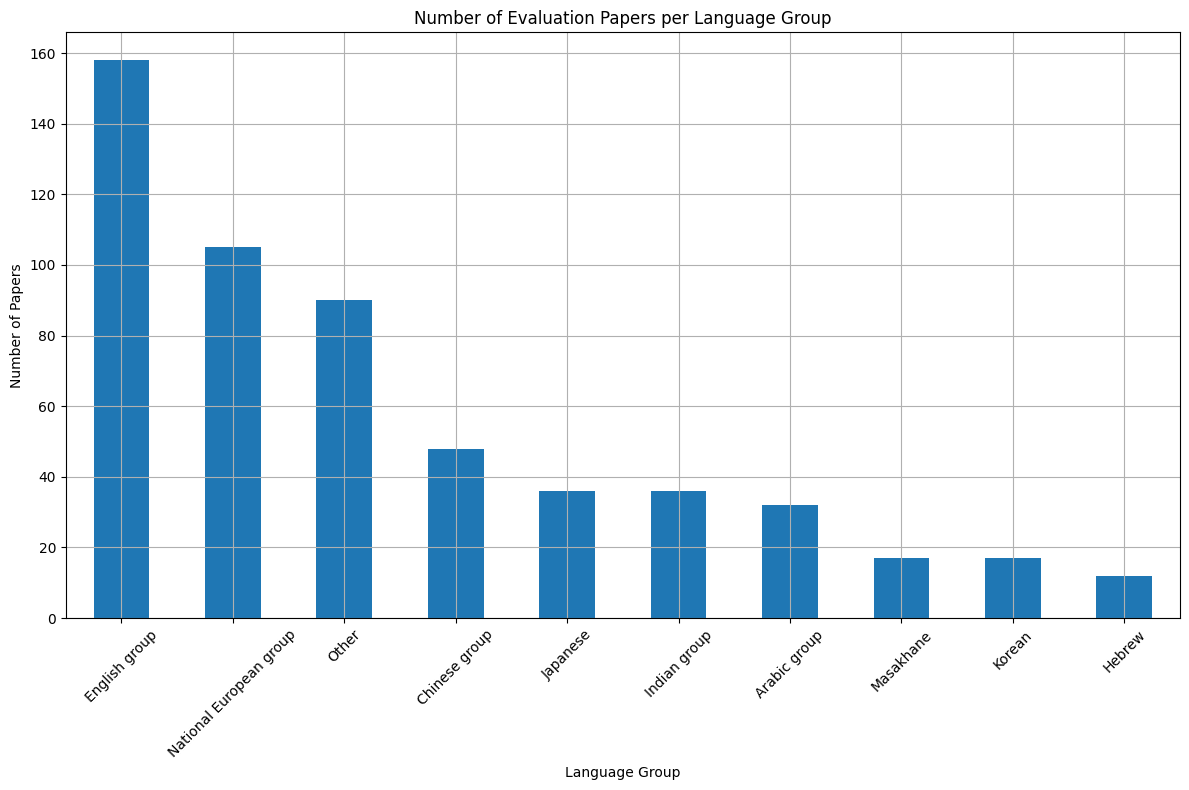

In [13]:
# Plot histogram of the number of papers per language group
groups = {'Other': 0}
for g in set(group_map.values()):
    groups[g] = 0
for langs in evaluation['languages']:
    lang_groups = set()
    for lang in langs:
        if lang in group_map:
            lang_groups.add(group_map[lang])
        else:
            lang_groups.add('Other')
    for g in lang_groups:
        groups[g] += 1
groups = pd.Series(groups).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
groups.plot(kind='bar')
plt.title('Number of Evaluation Papers per Language Group')
plt.xlabel('Language Group')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
europe = [
'old english','african american english','english','british sign language', 
'american sign language',
'limburgish','norwegian','swedish','old irish','swiss german',
'occitan','macedonian','greek','galician','ladin','venetian',
'hungarian','breton','ingrian','dutch','scottish gaelic', 
'low german','serbian','albanian','latgalian','ludian','basque',
'estonian','west frisian','ukrainian','french','icelandic', 
'portuguese','german','catalan','sicilian','danish','neapolitan',
'luxembourgish','bulgarian','gaelic','czech','slovenian',
'european languages','welsh','low saxon','middle french',
'middle high german','gothic','north norwegian','old french',
'lower sorbian','polish','lombard','lithuanian','bosnian',
'north frisian','norman','slovakian','mexican spanish', 
'middle low german','irish','romance languages','esperanto',
'old church slavonic','finnish','latvian','west norwegian',
'slavic languages','italian','ancient greek','old saxon','latin', 
'afrikaans','friulian','upper sorbian','tosk','silesian','romanian',
'croatian','spanish','slovak','alsatian german','cornish','russian',
'east norwegian','belarusian','manx','norwegian bokm','norwegian bokmål',
'norwegian nynorsk','karelian','eastern yiddish','yiddish','livvi',
'votic','picard','asturian','northern sami','kashubian','veps',
'faroese','livonian','maltese',
]
asia = [
'devanagari','konkani','dogri','chhattisgarhi','gujarati','punjabi',
'indian languages','hindi','eastern panjabi','bengali',
'kashmiri (arabic script)','kashmiri (devanagari script)','sindhi',
'kannada','sinhala','urdu','sanskrit','malayalam','tulu','awadhi',
'maithili','bhojpuri','dravidian','assamese',
'meiteilon (manipuri)','meitei',
'pali','telugu','odia','santali','magahi','marathi','braj bhasha',
'tamil','chinese (simplified)','chintang','dzongkha','chinese','yue chinese',
'ancient chinese','cantonese','chinese (traditional)',
'standard tibetan','tibetan','classical chinese','jingpho','mizo',
'myanmar','burmese','khaling','yongning na',
'filipino','shan','nepali','mongolian','cebuano','tagalog',
'sundanese','japanese','korean','austronesian','halh mongolian','vietnamese',
'khakas','south azerbaijani','classical armenian','central kurdish','uzbek',
'azerbaijani','kurdish','farsi','armenian','northern kurdish',
'kazakh','turkmen','turkish','kyrgyz','pangasinan','persian','uyghur',
'pashto','georgian','banjar','fijian','samoan','kabardian','waray',
'altaic','malaysian','dari','crimean tatar','tatar','indonesian',
'malay','standard malay','adyghe','bontoc','ainu','bashkir','khmer',
'acehnese','tajik','thai','javanese','mesopotamian arabic','arabic',
'modern standard arabic (latin)','classical arabic','modern standard arabic',
'levantine arabic','south levantine arabic','north levantine arabic',
'najdi arabic','gulf arabic','hebrew','classical syriac','akkadian','sumerian',
'tok pisin'
]

africa = [
'mboshi (bantu)','ewe','fon','shona','twi','african languages', 
'setswana','sesotho','isixhosa','rundi','kinyarwanda','umbundu',
'tumbuka','xhosa','bemba','igbo','yoruba','swahili','zulu',
'bambara','mossi','dyula','akan','kabiyè','northern sotho','ganda',
'tsonga','kikongo','kikuyu','chokwe','siswati','kamba','southwestern dinka',
'tamasheq','sango','amharic','nuer','kabiy','kimbundu','somali',
'hausa','central kanuri','west central oromo','tswana','wolof',
'luo','lingala','kabuverdianu','egyptian arabic','tunisian arabic','arabic',
'modern standard arabic (latin)','moroccan arabic','modern standard arabic',
'algerian arabic','maghrebi arabic','tigrinya',
]
america = [
'chatino','central aymara','aymara','guarani','quechua', 
'yucatec mayan','navajo','cherokee','yorem nokki',"itza'",
'tepehua','yupik','kalaallisut (west greenlandic)',
'tunumiisut (east greenlandic)','inuktun (north greenlandic)',
'greenlandic','inuktitut','yupik','hupa','chickasaw','asháninka',
'wixarika','seneca','bribri','mexicanero','popoluca','raramuri',
'nahuatl','odawa (ojibwe)','plains cree','arapaho','hñähñu',
'haitian creole','papiamento',
]
australia = ['kunwinjku','maori','murrinhpatha',]

continents_map = {}
for lang in europe:
    continents_map[lang] = 'Europe'
for lang in asia:
    continents_map[lang] = 'Asia'
for lang in africa:
    continents_map[lang] = 'Africa' 
for lang in america:
    continents_map[lang] = 'America'
for lang in australia:
    continents_map[lang] = 'Australia'

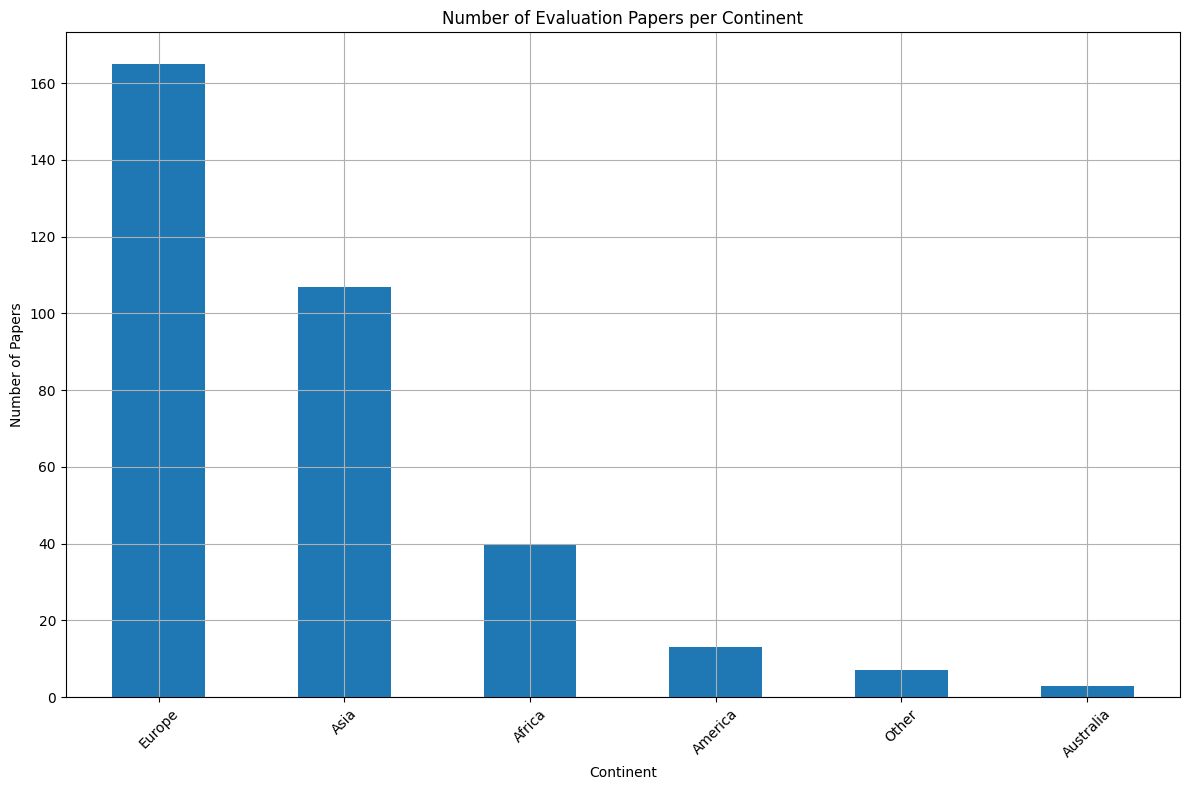

In [15]:
# Plot histogram of the number of papers per language group
groups = {'Other': 0}
for g in set(continents_map.values()):
    groups[g] = 0
for langs in evaluation['languages']:
    lang_groups = set()
    for lang in langs:
        if lang in continents_map:
            lang_groups.add(continents_map[lang])
        else:
            lang_groups.add('Other')
    for g in lang_groups:
        groups[g] += 1
groups = pd.Series(groups).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
groups.plot(kind='bar')
plt.title('Number of Evaluation Papers per Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Code

In [72]:
def f(x: str):
    if x is None or x == '':
        return False
    md = paper_dataset.get_markdown(x)
    if md is None:
        return False
    return llm_filter.has_pypi(md) or llm_filter.has_repository(md)
evaluation['has_code'] = evaluation['pdf_url'].progress_apply(f)
print(
    evaluation['has_code'].sum(),
    'papers with code out of', 
    len(evaluation),
    f"({evaluation['has_code'].sum()/len(evaluation)*100:.1f}%)"
)

100%|██████████| 173/173 [00:01<00:00, 152.69it/s]

101 papers with code out of 173 (58.4%)


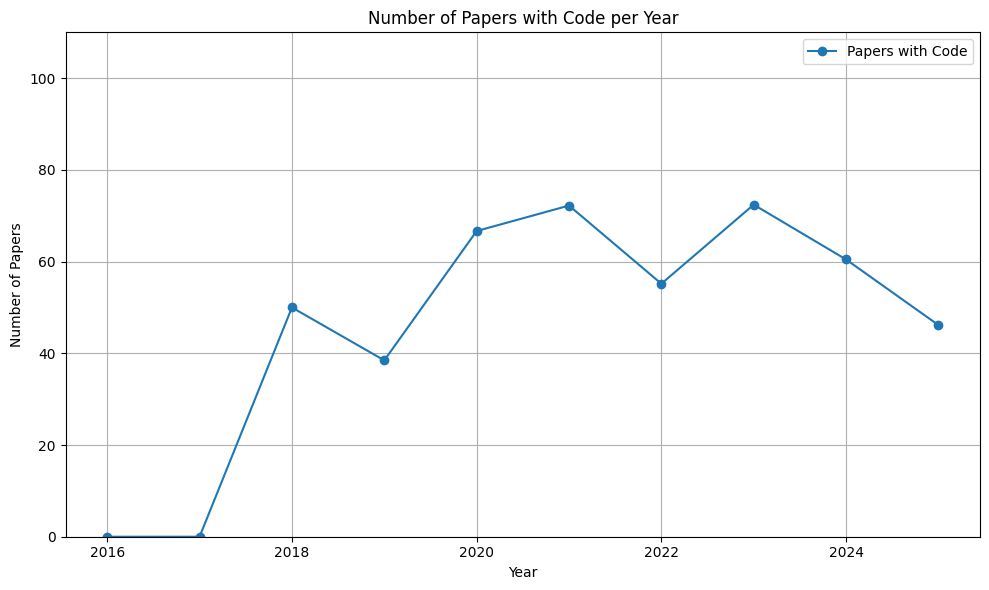

In [73]:
# Plot the number of papers with code over the years
years = sorted(evaluation['year'].unique())
code_counts = []
total_counts = []       
for year in years:  
    year_data = evaluation[evaluation['year'] == year]
    code_count = year_data[year_data['has_code'] == True].shape[0]
    total_count = year_data.shape[0]
    code_counts.append(code_count)
    total_counts.append(total_count)
plt.figure(figsize=(10, 6))
plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code_counts, total_counts)], marker='o', label='Papers with Code')
plt.title('Number of Papers with Code per Year')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.ylim(0, 110)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Metrics

In [ ]:
# def metrics(item):
#     md = paper_dataset.get_markdown(item['pdf_url'])
#     title = item['title'] if item['title'] is not None else ''
#     answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_METRICS, llm_filter.USER_PROMPT_METRICS, {'title': title, 'content': md}, local=True, max_tokens=1024)
#     return answer

# evaluation = paper_dataset.load('data/evaluation_papers.jsonl')
# all_answers = []
# for item in tqdm.tqdm(evaluation.iloc):
#     answer = metrics(item)
#     all_answers.append(answer)
    
# with open('evaluation_metric_answer.json', 'wt') as f:
#     json.dump(all_answers, f, indent=2)

0it [00:00, ?it/s]

INFO 10-16 10:07:53 [utils.py:328] non-default args: {'tensor_parallel_size': 4, 'disable_log_stats': True, 'model': 'meta-llama/Llama-3.3-70B-Instruct'}


Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/vico/personal_work_troja/huggingface/hub/models--meta-llama--Llama-3.3-70B-Instruct/.no_exist/6f6073b423013f6a7d4d9f39144961bfbfbc386b/preprocessor_config.json'


INFO 10-16 10:09:05 [__init__.py:742] Resolved architecture: LlamaForCausalLM


`torch_dtype` is deprecated! Use `dtype` instead!


...

(EngineCore_DP0 pid=3414075) (EngineCore_DP0 pid=3414075) (EngineCore_DP0 pid=3414075) (Worker_TP3 pid=3414103) (Worker_TP2 pid=3414100) (EngineCore_DP0 pid=3414075) (Worker_TP0 pid=3414097) 2025-10-16 10:16:50,199 - INFO - autotuner.py:256 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
2025-10-16 10:16:50,199 - INFO - autotuner.py:256 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(Worker_TP1 pid=3414099) 2025-10-16 10:16:50,200 - INFO - autotuner.py:256 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
2025-10-16 10:16:50,201 - INFO - autotuner.py:256 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore_DP0 pid=3414075) (EngineCore_DP0 pid=3414075) (Worker_TP3 pid=3414103) 2025-10-16 10:16:54,784 - INFO - autotuner.py:262 - flashinfer.jit: [Autotuner]: Autotuning process ends
(EngineCore_DP0 pid=3414075) (Worker_TP2 pid=3414100) (EngineCore_DP0 pid=3414075) (Worker_TP0 pid=3414097) 2025-10-16 10:16:54,782 - INFO - autotuner.p

(EngineCore_DP0 pid=3414075) (Worker_TP2 pid=3414100) INFO 10-16 10:17:44 [gpu_model_runner.py:3118] Graph capturing finished in 50 secs, took 3.96 GiB
(EngineCore_DP0 pid=3414075) (EngineCore_DP0 pid=3414075) (Worker_TP2 pid=3414100) INFO 10-16 10:17:44 [gpu_worker.py:391] Free memory on device (92.41/93.01 GiB) on startup. Desired GPU memory utilization is (0.9, 83.71 GiB). Actual usage is 32.89 GiB for weight, 2.03 GiB for peak activation, 0.45 GiB for non-torch memory, and 3.96 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=47491058892` to fit into requested memory, or `--kv-cache-memory=56828542976` to fully utilize gpu memory. Current kv cache memory in use is 51905563852 bytes.
(Worker_TP3 pid=3414103) (EngineCore_DP0 pid=3414075) INFO 10-16 10:17:44 [gpu_model_runner.py:3118] Graph capturing finished in 50 secs, took 3.96 GiB
(EngineCore_DP0 pid=3414075) (Worker_TP3 pid=3414103) INFO 10-16 10:17:44 [gpu_worker.py:391] Free memory on devi

Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/vico/personal_work_troja/huggingface/hub/models--meta-llama--Llama-3.3-70B-Instruct/.no_exist/6f6073b423013f6a7d4d9f39144961bfbfbc386b/processor_config.json'
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/vico/personal_work_troja/huggingface/hub/models--meta-llama--Llama-3.3-70B-Instruct/.no_exist/6f6073b423013f6a7d4d9f39144961bfbfbc386b/preprocessor_config.json'
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/vico/personal_work_troja/huggingface/hub/models--meta-llama--Llama-3.3-70B-Instruct/.no_exist/6f6073b423013f6a7d4d9f39144961bfbfbc386b/video_preprocessor_config.json'
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/vico/personal_work_troja/huggingface/hub/models--meta-

INFO 10-16 10:17:53 [chat_utils.py:538] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.


173it [28:58, 10.05s/it]


In [ ]:
evaluation = paper_dataset.load('data/evaluation_papers.jsonl')

with open('data/evaluation_metric_answer.json') as f:
    all_metrics = json.load(f)
all_metrics = [llm_filter.extract_metrics(i) for i in tqdm.tqdm(all_metrics)]

100%|██████████| 173/173 [00:00<00:00, 49364.90it/s]


In [6]:
tmp = itertools.chain.from_iterable(all_metrics)
sorted(list(set(tmp)))

['`acc` `$` ( `lm` [$] _θ_ )',
 '`acc` `1st` ( `lm` _θ_ )',
 '`acc` `ag` ( `lm` _θ_ )',
 '`acc` `cheat` ( `lm` _θ_ )',
 '`acc` `rev` ( `lm` _θ_ )',
 '`lm` _θ_ (ˆ _**r**_ = _**r**_ ; _**p**_ )',
 '`lm` _θ_ (ˆ _r_ _i_ = _r_ _i_ ; _**p**_ _,_ _**r**_ _<i_ )',
 'absolute tp method (tpa)',
 'accuracy',
 'accuracy (%)',
 'accuracy (a)',
 'accuracy (acc)',
 'accuracy (acc.)',
 'accuracy (for multinli and xnli tasks)',
 'accuracy (good, acceptable, bad)',
 'accuracy (implied by "the lower the better" for pk results)',
 'accuracy (in %) of different tools at predicting sentiment scores of neutral text alone (nt) or neutral text along with positive (+ve) or negative (-ve) emojis',
 'accuracy (m)',
 'accuracy (mm)',
 'accuracy by feat attestation (featsattested, featsnovel)',
 'accuracy by lemma attestation (lemmaattested, lemmanovel)',
 'accuracy by overlap partition (both, featsonly, lemmaonly, neither)',
 'accuracy for predicting semantic similarity between words',
 'accuracy of downstream cla

In [8]:
from collections import Counter
metric_counts = Counter()
for metrics in all_metrics:
    metric_counts.update(set(metrics))
print(len(metric_counts))
metric_counts

1127


Counter({'accuracy': 38,
         'precision': 30,
         'recall': 29,
         'f1 score': 27,
         'bleu': 23,
         'vocabulary size': 14,
         'bleu score': 13,
         'cosine similarity': 12,
         'f1': 12,
         'f1-score': 11,
         'perplexity': 10,
         'precision (p)': 8,
         'recall (r)': 8,
         'chrf': 8,
         'f-score': 8,
         'spearman correlation': 7,
         'dropout': 7,
         'comet': 6,
         'spearman’s ρ': 5,
         'pearson correlation': 5,
         'bertscore': 5,
         'meteor': 5,
         'learning rate': 5,
         'training time': 5,
         'cross-entropy': 4,
         'character error rate (cer)': 4,
         'bleurt': 4,
         'sequence length': 4,
         'p-value': 4,
         'standard deviation': 4,
         'word error rate (wer)': 4,
         'average sequence length': 4,
         'batch size': 4,
         'number of parameters': 4,
         'rouge': 4,
         'exact match (em)': 4

## UNITS

In [ ]:
# def units(item):
#     md = paper_dataset.get_markdown(item['pdf_url'])
#     title = item['title'] if item['title'] is not None else ''
#     answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_UNIT, llm_filter.USER_PROMPT_UNIT, {'title': title, 'content': md}, local=True, max_tokens=1024)
#     return answer

# evaluation = paper_dataset.load('data/evaluation_papers.jsonl')
# all_answers = []
# for item in tqdm.tqdm(evaluation.iloc, total=len(evaluation)):
#     answer = units(item)
#     all_answers.append(answer)
    
# with open('evaluation_unit_answer.json', 'wt') as f:
#     json.dump(all_answers, f, indent=2)

  0%|                                                                                                                                                                                      | 0/173 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 173/173 [08:56<00:00,  3.10s/it]


##

In [27]:
def clean_unit(units):
    clean = []
    for unit in units:
        unit = unit.lower().strip()
        if unit == "unicode characters":
            clean.append("characters")
        elif unit == "token":
            clean.append("tokens")
        elif unit == "subword tokens":
            clean.append("subwords")
        elif unit == "subword":
            clean.append("subwords")
        elif unit == "character":
            clean.append("characters")
        elif unit == "morpheme":
            clean.append("morphemes")
        elif "\n" in unit or ")" in unit:
            pass
        else:
            clean.append(unit)
    return clean

In [28]:
evaluation = paper_dataset.load('data/evaluation_papers.jsonl')

with open('data/evaluation_unit_answer.json') as f:
    all_units = json.load(f)
all_units = [clean_unit(llm_filter.extract_units(i)) for i in tqdm.tqdm(all_units)]


100%|██████████| 173/173 [00:00<00:00, 97098.17it/s]


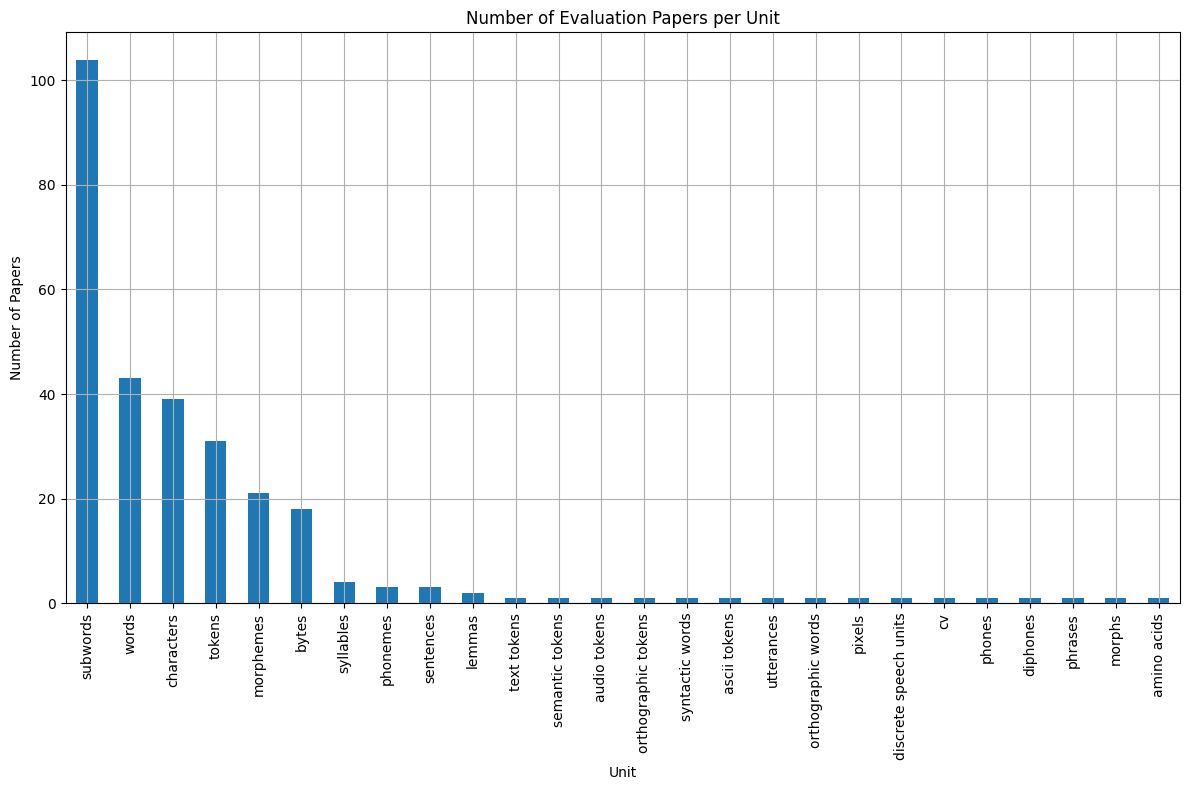

In [29]:
# Plot histogram of the number of papers per unit
all_units_flat = [unit for sublist in all_units for unit in sublist]
all_units_flat = pd.Series(all_units_flat).value_counts()
plt.figure(figsize=(12, 8))
all_units_flat.plot(kind='bar')
plt.title('Number of Evaluation Papers per Unit')
plt.xlabel('Unit')
plt.ylabel('Number of Papers')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
from collections import Counter
unit_counts = Counter([tuple(i) for i in all_units])
unit_counts.most_common(15)

[(('subwords',), 60),
 (('tokens',), 23),
 (('words',), 11),
 (('morphemes',), 7),
 (('characters',), 6),
 (('characters', 'subwords', 'words'), 6),
 (('characters', 'words'), 5),
 (('bytes', 'characters', 'subwords'), 5),
 (('morphemes', 'subwords'), 4),
 (('subwords', 'words'), 4),
 (('characters', 'subwords'), 4),
 (('bytes', 'subwords'), 3),
 (('subwords', 'tokens', 'words'), 2),
 (('bytes',), 2),
 (('bytes', 'morphemes', 'subwords', 'tokens'), 1)]

## Motivation

In [11]:
def motivation(item):
    md = paper_dataset.get_markdown(item['pdf_url'])
    title = item['title'] if item['title'] is not None else ''
    answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_MOTIVATION, llm_filter.USER_PROMPT_MOTIVATION, {'title': title, 'content': md}, local=True, max_tokens=1024)
    return answer

evaluation = paper_dataset.load('data/evaluation_papers.jsonl')
all_answers = []
for item in tqdm.tqdm(evaluation.iloc, total=len(evaluation)):
    answer = motivation(item)
    all_answers.append(answer)
    
with open('evaluation_motivation_answer.json', 'wt') as f:
    json.dump(all_answers, f, indent=2)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 173/173 [19:14<00:00,  6.68s/it]
